<a href="https://colab.research.google.com/github/Priji123/Mtech_final_year_project/blob/main/Proper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Dataset

In [ ]:
!pip install kagglehub


   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   ---------- ----------------------------- 1/4 [protobuf]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -----------

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
aniruddhsharma_structural_defects_network_concrete_crack_images_path = kagglehub.dataset_download('aniruddhsharma/structural-defects-network-concrete-crack-images')

print('Data source import complete.')


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 506M/506M [28:29<00:00, 310kB/s]

Extracting files...


Data source import complete.


# Importing Libraries

In [ ]:
!pip install opencv-python numpy tqdm scikit-image

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 799.2 kB/s eta 0:00:50
    --------------------------------------- 0.5/40.2 MB 799.2 kB/s eta 0:00:50
    --------------------------------------- 0.8/40.2 MB 671.3 kB/s eta 0:00:59
    --------------------------------------- 0.8/40.2 MB 671.3 kB/s eta 0:00:59
   - -------------------------------------- 1.0/40.2 MB 671.0 kB/s eta 0:00:59
   - -------------------------------------- 1.0/40.2 MB 671.0 kB/s eta 0:00:59
   - -------------------------------------- 1.3/40.2 MB 664.5 kB/s eta 0:00:59
   - -------------------------------------- 1.3/40.2 MB 664.5 kB/s eta 0:00:59
   - -------------------------------------- 1.6/40.2 MB 616.8 kB/s eta 0:01:03
   - ----

In [ ]:
pip install scikit-image

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.9 MB 2.6 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.9 MB 2.9 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.9 MB 2.6 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.9 MB 2.3 MB/s eta 0:00:05
   ------- -------------------------------- 2.4/11.9 MB 1.9 MB/s eta 0:00:05
   -------- ------------------------------- 2.6/11.9 MB 1.9 MB/s eta 0:00:05
   ---------- ----------------------------- 3.1/11.9 MB 1.8 MB/s eta 0:00:05
   ----------- ---------------------------- 3.4/11.9 MB 1.9 MB/s eta 0:00:05
   ------------- -------------------------- 3.9/11.9 MB 1.9 MB/s eta 0:00:05
   -------------- ------------------------- 4.5/11.9 MB 2.0 MB/s eta 0:00:04
   ----------------- ----

In [ ]:
import os
import cv2
import glob
import numpy as np
from tqdm import tqdm
from skimage.filters import frangi

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


KeyboardInterrupt



#Dataset Path

In [ ]:
SDNET_ROOT = "1"

CATEGORIES = ["Walls", "Decks", "Pavements"]

#Output Dataset Folder

In [ ]:
OUT_ROOT = "dataset_unet_full"

IMG_OUT = os.path.join(OUT_ROOT, "images")
MASK_OUT = os.path.join(OUT_ROOT, "masks")

os.makedirs(IMG_OUT, exist_ok=True)
os.makedirs(MASK_OUT, exist_ok=True)

#Image Size

In [ ]:
IMG_SIZE = 256

#CRACK MASK GENERATOR (Frangi-based pseudo labels)


In [ ]:
def create_crack_mask(gray):

    # Smooth while preserving edges
    blur = cv2.bilateralFilter(gray, 9, 75, 75) ##Edge preserving Smoothening

    # Improve contrast
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blur)

    # Normalize for Frangi filter
    img_norm = enhanced / 255.0

    # Enhance crack-like structures
    frangi_response = frangi(
        img_norm,
        sigmas=range(1,4),
        black_ridges=True
    )

    # Adaptive threshold
    threshold = frangi_response.mean() + frangi_response.std()

    mask = (frangi_response > threshold).astype(np.uint8) * 255

    # Morphological cleanup
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Remove small components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    clean = np.zeros_like(mask)
    min_area = 200

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            clean[labels == i] = 255

    return clean


# Create Image-Mask Pairs

In [ ]:
idx = 0

valid_ext = ("*.jpg","*.jpeg","*.png","*.bmp")

for category in CATEGORIES:

    cracked_dir = os.path.join(SDNET_ROOT, category, "Cracked")
    noncracked_dir = os.path.join(SDNET_ROOT, category, "Non-cracked")

    cracked_paths = []
    noncracked_paths = []

    for ext in valid_ext:
        cracked_paths.extend(glob.glob(os.path.join(cracked_dir, ext)))
        noncracked_paths.extend(glob.glob(os.path.join(noncracked_dir, ext)))

    cracked_paths = sorted(cracked_paths)
    noncracked_paths = sorted(noncracked_paths)

    print(f"\n📂 Processing {category}")
    print("   ➤ Cracked:", len(cracked_paths))
    print("   ➤ Non-cracked:", len(noncracked_paths))

    # ===============================
    # PROCESS CRACKED IMAGES
    # ===============================

    for path in tqdm(cracked_paths, desc=f"{category} - Cracked"):

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        mask = create_crack_mask(gray)

        name = f"{idx:06d}.png"

        cv2.imwrite(os.path.join(IMG_OUT, name), img)
        cv2.imwrite(os.path.join(MASK_OUT, name), mask)

        idx += 1
    # ===============================
    # PROCESS NON-CRACKED IMAGES
    # ===============================

    for path in tqdm(noncracked_paths, desc=f"{category} - Non-cracked"):

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        empty_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        name = f"{idx:06d}.png"

        cv2.imwrite(os.path.join(IMG_OUT, name), img)
        cv2.imwrite(os.path.join(MASK_OUT, name), empty_mask)

        idx += 1


print("\n✅ Dataset Creation Completed")
print("Total image-mask pairs:", idx)
print("Images folder:", IMG_OUT)
print("Masks folder :", MASK_OUT)

NameError: name 'CATEGORIES' is not defined

# Train Validation Split

In [ ]:
from sklearn.model_selection import train_test_split
import glob
import os

# Paths to generated dataset
IMAGE_DIR = "C:\\Users\\student\\Documents\\Priji\\archive\\train\\images"
MASK_DIR = "C:\\Users\\student\\Documents\\Priji\\archive\\train\\masks"

# Collect image and mask paths
images = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
masks  = sorted(glob.glob(os.path.join(MASK_DIR, "*.jpg")))

print("Total Images:", len(images))
print("Total Masks :", len(masks))

# Split dataset (80% train, 20% validation)
train_images, val_images, train_masks, val_masks = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("\nDataset Split")
print("Training Images:", len(train_images))
print("Validation Images:", len(val_images))

Total Images: 9603
Total Masks : 9603

Dataset Split
Training Images: 7682
Validation Images: 1921


# Tensorflow Dataset Pipeline

In [ ]:
import tensorflow as tf
import cv2
import numpy as np

IMG_SIZE = 448
BATCH_SIZE = 8


def load_image(img_path, mask_path):

    img_path = img_path.decode()
    mask_path = mask_path.decode()

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    mask = cv2.imread(mask_path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)

    return img.astype(np.float32), mask.astype(np.float32)


def tf_parse(img, mask):

    img, mask = tf.numpy_function(
        load_image,
        [img, mask],
        [tf.float32, tf.float32]
    )

    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return img, mask


# Training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_masks))
train_dataset = train_dataset.map(tf_parse)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)


# Validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_masks))
val_dataset = val_dataset.map(tf_parse)
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)

Train Dataset: <PrefetchDataset element_spec=(TensorSpec(shape=(None, 448, 448, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 448, 448, 1), dtype=tf.float32, name=None))>
Validation Dataset: <PrefetchDataset element_spec=(TensorSpec(shape=(None, 448, 448, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 448, 448, 1), dtype=tf.float32, name=None))>


# Build Attention U-Net Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# --------------------------------
# Convolution Block
# --------------------------------
def conv_block(x, num_filters):

    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    return x


# --------------------------------
# Encoder Block
# --------------------------------
def encoder_block(x, num_filters):

    s = conv_block(x, num_filters)
    p = L.MaxPool2D((2, 2))(s)

    return s, p


# --------------------------------
# Attention Gate
# --------------------------------
def attention_gate(g, s, num_filters):

    Wg = L.Conv2D(num_filters, 1, padding="same")(g)
    Wg = L.BatchNormalization()(Wg)

    Ws = L.Conv2D(num_filters, 1, padding="same")(s)
    Ws = L.BatchNormalization()(Ws)

    out = L.Activation("relu")(Wg + Ws)
    out = L.Conv2D(1, 1, padding="same", activation="sigmoid")(out)

    return L.Multiply()([out, s])


# --------------------------------
# Decoder Block
# --------------------------------
def decoder_block(x, s, num_filters):

    x = L.UpSampling2D(interpolation="bilinear")(x)

    s = attention_gate(x, s, num_filters)

    x = L.Concatenate()([x, s])

    x = conv_block(x, num_filters)

    return x


# --------------------------------
# Build Attention U-Net
# --------------------------------
def build_attention_unet(input_shape=(448, 448, 3)):

    inputs = L.Input(input_shape)

    # Encoder (lighter)
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    # Bridge
    b1 = conv_block(p4, 512)

    # Decoder
    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = L.Conv2D(
        1, 1,
        padding="same",
        activation="sigmoid",
        dtype="float32"   # important for mixed precision
    )(d4)

    model = tf.keras.Model(inputs, outputs, name="Attention_U-Net")

    return model


# Build model
model = build_attention_unet()

model.summary()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 2070 SUPER, compute capability 7.5
Model: "Attention_U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 448, 448, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 448, 448, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                   

# Loss Function and Metrics

In [ ]:
import tensorflow as tf



# -----------------------------
# Dice Coefficient Metric
# -----------------------------
def dice_coef(y_true, y_pred):

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2.0 * intersection + 1e-6) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-6
    )


# -----------------------------
# Tversky Loss
# -----------------------------
class TverskyLoss(tf.keras.losses.Loss):

    def __init__(self, alpha=0.7, beta=0.3):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def call(self, y_true, y_pred):

        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        tp = tf.reduce_sum(y_true * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        fp = tf.reduce_sum((1 - y_true) * y_pred)

        tversky = (tp + 1e-6) / (tp + self.alpha * fn + self.beta * fp + 1e-6)

        return 1 - tversky

# Compile and Train the Model

In [ ]:
# ===============================
# Compile Model
# ===============================

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=TverskyLoss(),
    metrics=[dice_coef]
)




# ===============================
# Callbacks
# ===============================

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_dice_coef",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# ===============================
# Train Model
# ===============================

EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 1/30
961/961 [==============================] - ETA: 0s - loss: 0.5413 - dice_coef: 0.3713
Epoch 1: val_dice_coef improved from -inf to 0.45318, saving model to best_model.h5
961/961 [==============================] - 441s 426ms/step - loss: 0.5413 - dice_coef: 0.3713 - val_loss: 0.4544 - val_dice_coef: 0.4532 - lr: 1.0000e-04
Epoch 2/30
961/961 [==============================] - ETA: 0s - loss: 0.3850 - dice_coef: 0.5459
Epoch 2: val_dice_coef improved from 0.45318 to 0.57382, saving model to best_model.h5
961/961 [==============================] - 406s 422ms/step - loss: 0.3850 - dice_coef: 0.5459 - val_loss: 0.3550 - val_dice_coef: 0.5738 - lr: 1.0000e-04
Epoch 3/30
961/961 [==============================] - ETA: 0s - loss: 0.3309 - dice_coef: 0.6139
Epoch 3: val_dice_coef improved from 0.57382 to 0.62628, saving model to best_model.h5
961/961 [==============================] - 398s 414ms/step - loss: 0.3309 - dice_coef: 0.6139 - val_loss: 0.3263 - val_dice_coef: 0.6263 - lr: 

# Evaluate and Visualize Predictions

In [ ]:
import pandas as pd

# Convert history to dataframe
history_df = pd.DataFrame(history.history)

# Save to CSV
history_df.to_csv("training_results.csv", index=False)

print("Training results saved to training_results.csv")

Training results saved to training_results.csv


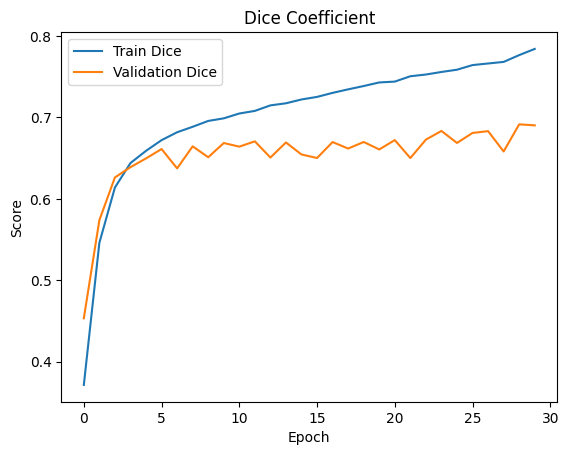

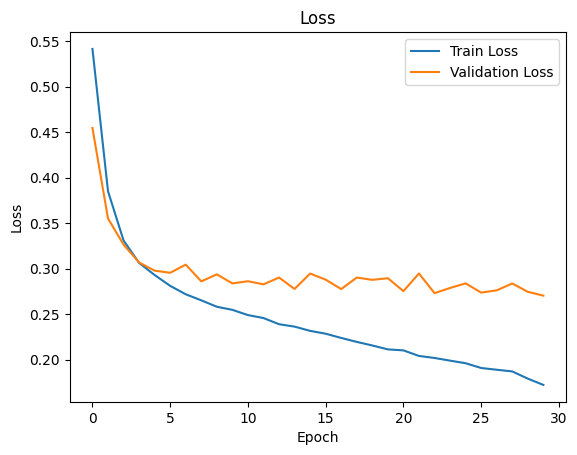

In [ ]:
import matplotlib.pyplot as plt

# Dice score
plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')
plt.legend()
plt.title("Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.savefig("dice_score.png")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("loss_curve.png")
plt.show()